# Data & Tools Exploration

## Questions

In [38]:
import json
import polars as pl
data_path = "../data/EnterpriseRAG-Bench"

In [2]:
with open(f"{data_path}/questions.jsonl", "r") as f:
    questions = [json.loads(line) for line in f]
# convert questions json list into dataframe
with open(f"{data_path}/extra_questions.jsonl", "r") as f:
    questions_extra = [json.loads(line) for line in f]
questions_df = pl.DataFrame(questions+questions_extra)

In [3]:
print(len(questions_df))
print(questions_df.group_by(['source_types']).agg(pl.col('question_id').count()).sort(by='question_id', descending=True).head(10))

600
shape: (10, 2)
┌──────────────────┬─────────────┐
│ source_types     ┆ question_id │
│ ---              ┆ ---         │
│ list[str]        ┆ u32         │
╞══════════════════╪═════════════╡
│ ["confluence"]   ┆ 76          │
│ ["jira"]         ┆ 76          │
│ ["slack"]        ┆ 62          │
│ ["linear"]       ┆ 58          │
│ ["google_drive"] ┆ 56          │
│ ["github"]       ┆ 50          │
│ ["hubspot"]      ┆ 49          │
│ ["gmail"]        ┆ 48          │
│ []               ┆ 30          │
│ ["fireflies"]    ┆ 27          │
└──────────────────┴─────────────┘


In [4]:
print(len(questions_df.filter(pl.col('source_types').list.contains("confluence"))))
questions_df.filter(pl.col('source_types').list.contains("confluence")).group_by(['source_types']).agg(pl.col('question_id').count()).sort(by='question_id', descending=True)

126


source_types,question_id
list[str],u32
"[""confluence""]",76
"[""confluence"", ""jira""]",6
"[""confluence"", ""google_drive""]",6
"[""confluence"", ""linear""]",5
"[""confluence"", ""github"", ""jira""]",5
…,…
"[""confluence"", ""linear"", ""slack""]",1
"[""confluence"", ""github"", … ""linear""]",1
"[""confluence"", ""github"", … ""slack""]",1


In [5]:
print(len(questions_df.filter(pl.col('source_types').list.contains("jira"))))
questions_df.filter(pl.col('source_types').list.contains("jira")).group_by(['source_types']).agg(pl.col('question_id').count()).sort(by='question_id', descending=True)

116


source_types,question_id
list[str],u32
"[""jira""]",76
"[""confluence"", ""jira""]",6
"[""confluence"", ""github"", ""jira""]",5
"[""confluence"", ""github"", … ""jira""]",3
"[""github"", ""jira""]",3
…,…
"[""confluence"", ""google_drive"", … ""slack""]",1
"[""gmail"", ""google_drive"", … ""slack""]",1
"[""confluence"", ""google_drive"", … ""slack""]",1


In [6]:
questions_df.filter(pl.col('source_types').list.contains("confluence"))[0]

question_id,question_type,source_types,question,expected_doc_ids,gold_answer,answer_facts
str,str,list[str],str,list[str],str,list[str]
"""qst_0011""","""basic""","[""confluence""]","""How long is the validity perio…","[""dsid_46a4cb87db414e769f2df86f01626948""]","""The ""Telemetry-Driven Runbook …","[""The Telemetry-Driven Runbook Author (Redwood) certification is valid for 18 months.""]"


- 76 questions to test "confluence" only data source
- 76 questions to test "confluence" only data source

## Raw Data (Confluence)

In [7]:
# document length
# iterate reading txt files under f"{data_path}/confluence/"

import glob, re, os
docs = []
docs_confluence = []
for path in glob.glob(f"{data_path}/confluence/*.txt"):
    text = open(path, encoding="utf-8").read()
    m = re.match(r"dsid_([0-9a-f]+)__(.+)\.txt", os.path.basename(path))
    doc_id, title = (m.group(1), m.group(2)) if m else ("", os.path.basename(path))
    docs_confluence.append({"doc_id": doc_id, "title": title, "text": text, "source": path})

### text length

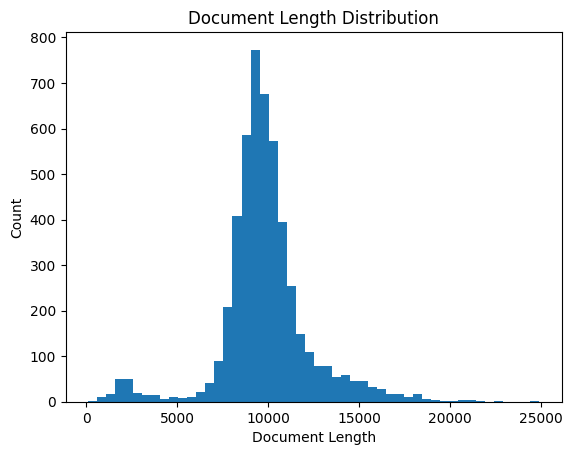

Average document length: 9829.171


In [8]:
import matplotlib.pyplot as plt

docs_confluence_len = [len(d["text"]) for d in docs_confluence]
plt.hist(docs_confluence_len, bins=50)
plt.title("Document Length Distribution")
plt.xlabel("Document Length")
plt.ylabel("Count")
plt.show()

print(f"Average document length: {sum(docs_confluence_len)/len(docs_confluence_len)}")

### text structure

看这几项的意义:

- 长度百分位数(不是均值):决定全局一个 chunk_size 是否够,还是得自适应。集中度高的话一个值通吃。
- 标题结构:# 标题平均每篇多少?印证之前"只有 ~20% 有 #"的结论 → heading split 不能一刀切。
- 列表/表格密度:列表和 | 表最怕从中间切断,密度高的文档要优先保护边界。
- 代码块数:YAML/CLI 不能切在块中间。
- gold_answer 长度:它大致等于"一个好答案需要的上下文量"。如果你的 chunk 比它小太多,单段可能喂不饱答案;比它大太多,又混入噪点。用这个数反推 chunk_size 最准。

In [9]:
import re
texts = [d["text"] for d in docs_confluence]

def pct(x, p):
    s = sorted(x); k = (len(s)-1)*p; f = int(k)
    return s[f] if f+1 >= len(s) else s[f] + (s[f+1]-s[f])*(k-f)

lens = [len(t) for t in texts]
print("chars p50/p90/p99/min/max:",
      round(pct(lens,.5)), round(pct(lens,.9)), round(pct(lens,.99)), min(lens), max(lens))

def stats(t):
    lines = t.split("\n")
    md_h   = sum(1 for l in lines if re.match(r'^#{1,6}\s', l))            # Markdown #
    plain_h= sum(1 for i,l in enumerate(lines) if 0<i<len(lines)-1
                 and 0 < len(l.strip()) < 70 and l.strip()[:1].isupper()
                 and not l.strip().startswith(("-","*","|","#"))
                 and not l.strip().endswith(".") and len(l.strip().split()) <= 8)
    bullets = sum(1 for l in lines if re.match(r'^\s*[-*]\s', l))
    tables  = sum(1 for l in lines if l.strip().startswith("|") and l.strip().count("|") >= 2)
    code    = len(re.findall(r'```', t)) // 2
    return md_h, plain_h, bullets, tables, code

a = list(zip(*[stats(t) for t in texts]))
print("avg Markdown-# headings/doc :", round(sum(a[0])/len(texts),1))
print("avg plain-text headings/doc :", round(sum(a[1])/len(texts),1))
print("avg bullet lines/doc        :", round(sum(a[2])/len(texts),1))
print("avg table rows/doc          :", round(sum(a[3])/len(texts),1))
print("avg code blocks/doc         :", round(sum(a[4])/len(texts),1))

# 金标准答案长度 = 理想的"检索单元"大小参考
ga = [len(str(q["gold_answer"])) for q in questions_df.iter_rows(named=True)]
print("gold_answer chars p50/p90  :", round(pct(ga,.5)), round(pct(ga,.9)))

chars p50/p90/p99/min/max: 9636 12532 17500 104 24881
avg Markdown-# headings/doc : 4.7
avg plain-text headings/doc : 15.6
avg bullet lines/doc        : 52.5
avg table rows/doc          : 3.8
avg code blocks/doc         : 0.4
gold_answer chars p50/p90  : 209 809


In [10]:
# 表格行/doc
docs_confluence_table_rows = [stats(d["text"])[3] for d in docs_confluence]
i=0
for tr, dt in zip(docs_confluence_table_rows, docs_confluence):
    if tr > 0:
        print(f"\n=== table documents example {i} ===")
        print(f"{tr} table rows in {dt['title']} ({dt['doc_id']})")
        print("--- here how table rows look like ---")
        for l in dt["text"].split("\n"):
            if l.strip().startswith("|") and l.strip().count("|") >= 2:
                print(l)
        i+=1
    if i>=2: break


=== table documents example 0 ===
4 table rows in service-traffic-topology-and-adaptive-shaping-guide-2026 (0dd4dcc98daa4a81896c79c0ca232a30)
--- here how table rows look like ---
| Source (tenant) | Region | Preferred pool | p99_ms (1m) | KV_hit_rate | Burst_balance | Notes |
| ACME | us-west-2 | gpu-pool-3-hot | 430 | 0.78 | 640 | interactive-heavy |
| acme-dataflow | us-west-2 | gpu-pool-5-cold | 1200 | 0.22 | 50 | background batch, migrate |
| betacorp | eu-central | gpu-pool-2-hot | 210 | 0.92 | 1200 | high-priority, SLA-99 |

=== table documents example 1 ===
6 table rows in forensic-ready-compliance-playbook-for-emergency-deployments-2025 (8b58fca07ca34699bb2cce932e3dd24d)
--- here how table rows look like ---
| artifact_type | default_retention | legal_hold_retention | storage_location | notes |
|---------------|-------------------|----------------------|------------------|-------|
| audit-jsonl | 1 year | 7 years | s3://audit-archive/{region}/ | signed by evidence-orchestrato

## Test Text Splitters

In [11]:
text = docs_confluence[0]["text"]

In [37]:
docs_confluence[0]["doc_id"]

'0dd4dcc98daa4a81896c79c0ca232a30'

In [17]:
from langchain_text_splitters import CharacterTextSplitter
splitter = CharacterTextSplitter(
   separator="\n\n",
   chunk_size=1500,
   chunk_overlap=200,
   strip_whitespace=True
)
chunks = splitter.split_text(text)
print("chunks:", len(chunks), "avg:", sum(map(len, chunks)) // len(chunks))
#for i, c in enumerate(chunks):
#    print(f"--- chunk {i} ---\n{c}")

chunks: 7 avg: 1312


In [22]:
print(chunks[3])

CLI (example):
- Apply policy: 
  rctl policy apply --tenant=acme --policy-file=interactive-standard.yaml --env=prod
- Query topology: 
  rctl topology describe --tenant=acme --format=table

Dashboard and alerting guidance

Recommended dashboard panels (per-tenant / per-model):
- Real-time topology heatmap: source -> pool latency (color-coded)
- SLI trend: p50/p95/p99 latency (1m, 5m), with SLO lines
- Burst credit balance and refill rate histogram
- Concurrency cap and current active requests
- KV cache hit rate and model load trend

Suggested alert rules (Prometheus-style expressions):
1) High p99 breach:
  expr: max_over_time(p99_latency_ms[5m]) > tenant_p99_slo_ms * 1.2
  for: 3m
  severity: P1
2) Rapid burst depletion:
  expr: rate(burst_credit_balance[1m]) < - (burst_refill_per_min / 60) * 2
  for: 2m
  severity: P2
3) Cold-pool overload:
  expr: avg_over_time(pool_utilization[2m]) > 0.85 and avg_over_time(kv_hit_rate[2m]) < 0.6
  severity: P2

Alert routing: P1 -> oncall SRE + p

In [24]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
   chunk_size=1500,
   chunk_overlap=250,
   separators=["\n\n", "\n", ". ", " "],
   keep_separator=False
)
chunks = splitter.split_text(text)
print("chunks:", len(chunks), "avg:", sum(map(len, chunks)) // len(chunks))

chunks: 7 avg: 1355


In [35]:
print(chunks[6])

Ownership and contacts

- Design and implementation: Platform Traffic Team (primary owner).
- Observability dashboards: Telemetry Platform Team.
- Runbook maintenance: SRE Team.

Appendix: Example topology table (text)

| Source (tenant) | Region | Preferred pool | p99_ms (1m) | KV_hit_rate | Burst_balance | Notes |
| ACME | us-west-2 | gpu-pool-3-hot | 430 | 0.78 | 640 | interactive-heavy |
| acme-dataflow | us-west-2 | gpu-pool-5-cold | 1200 | 0.22 | 50 | background batch, migrate |
| betacorp | eu-central | gpu-pool-2-hot | 210 | 0.92 | 1200 | high-priority, SLA-99 |

If you have questions or propose policy changes, comment on this page or ping the Platform Traffic Team in #platform-traffic.

Change log:
- 2025-11-12: Drafted initial design (Aisha Patel).
- 2026-01-15: Incorporated telemetry team feedback; tuned thresholds (Marco Ruiz).
- 2026-02-03: Added Q4 2025 retrospective and roadmap (Sophie Chen).
